In [1]:
from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.utils import FRED
from SymbolicDSGE.utils.math_utils import HP_two_sided, annualized_log_percent, detrend
from SymbolicDSGE.bayesian import make_prior
from SymbolicDSGE.regression import (
    SymbolicRegressor,
    TemplateConfig,
    PySRParams,
    ModelParametrizer,
)

from sympy import Matrix, Symbol, print_latex, Rational
from warnings import catch_warnings, simplefilter

from numpy import array, float64, ceil, sqrt, log, std, random, isclose
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import cProfile

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
model, kalman = ModelParser("../MODELS/POST82.yaml").get_all()

with catch_warnings():
    # Equations in a sp.Matrix are deprecated, this is only used as a pretty print function
    simplefilter(action="ignore")
    mat = Matrix(model.equations.model)
mat

Matrix([
[                                    Eq(Pi(t), beta*Pi(t + 1) + kappa*(x(t) - z(t)))],
[                           Eq(x(t), -tau_inv*(-Pi(t + 1) + r(t)) + g(t) + x(t + 1))],
[Eq(r(t), e_r + rho_r*r(t - 1*1) + (1 - rho_r)*(psi_pi*Pi(t) + psi_x*(x(t) - z(t))))],
[                                                   Eq(g(t), e_g + rho_g*g(t - 1*1))],
[                                                   Eq(z(t), e_z + rho_z*z(t - 1*1))]])

In [3]:
fred = FRED(
    key_env=None,  # None => look for the ".env" file. If you have a custom env file, provide its path here.
    key_name="FRED_KEY",  # Name of the variable in the env file that contains the FRED API key.
)
df = fred.get_frame(
    series_ids=[
        "GDPC1",  # Real GDP
        "CPIAUCSL",  # Consumer Price Index for All Urban Consumers: All Items
        "FEDFUNDS",  # Effective Federal Funds Rate
    ],
    date_range=(
        "1955-01-01",
        "2007-10-01",
    ),  # Date range for the data ("YYYY-MM-DD" format or a pd.DatetimeIndex object)
)

gdp_q = df["GDPC1"]  # already quarterly in most pulls; verify freq

cpi_q = df["CPIAUCSL"].resample("QS").mean()  # quarterly avg CPI
ffr_q = df["FEDFUNDS"].resample("QS").mean()  # quarterly avg policy rate

idx_range = pd.date_range(start="1984-01-01", end="2007-01-01", freq="QS")


df = pd.DataFrame(
    {
        "GDPC1": gdp_q.reindex(idx_range),
        "CPIAUCSL": cpi_q.reindex(idx_range),
        "FEDFUNDS": ffr_q.reindex(idx_range),
    }
)

df

,GDPC1,CPIAUCSL,FEDFUNDS
1984-01-01,8034.847,102.533333,9.686667
1984-04-01,8173.670,103.500000,10.556667
1984-07-01,8252.465,104.400000,11.390000
1984-10-01,8320.199,105.300000,9.266667
1985-01-01,8400.820,106.266667,8.476667
...,...,...,...
2006-01-01,16353.835,199.466667,4.456667
2006-04-01,16396.151,201.266667,4.906667
2006-07-01,16420.738,203.166667,5.246667
2006-10-01,16561.866,202.333333,5.246667


In [4]:
x_trend = HP_two_sided(log(df["GDPC1"]), lamb=1600)[0]  # returns (trend, cycle)
x = (log(df["GDPC1"]) - x_trend) * 100  # HP detrended quarterly log output gap


inf_lvl = annualized_log_percent(df["CPIAUCSL"], periods_per_year=4)
rate_lvl = df["FEDFUNDS"]

r_ss = model.calibration.parameters["r_star"]
pi_ss = model.calibration.parameters["pi_star"]

rate = (rate_lvl - (r_ss + pi_ss)) / 4  # gap to steady state
inf = (inf_lvl - pi_ss) / 4  # gap to steady state

df_model_units = pd.DataFrame(
    {
        "r": rate,
        "Pi": inf,
        "x": x,
    }
).dropna()

observed = pd.DataFrame(
    {
        "OutGap": x[df_model_units.index],
        "Infl": inf_lvl[df_model_units.index],
        "Rate": rate_lvl[df_model_units.index],
    }
)
observed.index = df_model_units.index

In [5]:
prior_spec = {
    # (0, 1)
    "beta": make_prior(
        "beta",
        parameters={"a": 200 * 0.99, "b": 200 * 0.001},
        transform="logit",
    ),
    "rho_r": make_prior(
        "beta",
        parameters={"a": 200 * 0.84, "b": 200 * 0.16},
        transform="logit",
    ),
    "rho_g": make_prior(
        "beta",
        parameters={"a": 200 * 0.83, "b": 200 * 0.17},
        transform="logit",
    ),
    "rho_z": make_prior(
        "beta",
        parameters={"a": 200 * 0.85, "b": 200 * 0.15},
        transform="logit",
    ),
    # (0, +inf)
    "psi_pi": make_prior(
        "gamma",
        parameters={"mean": 2.19, "std": 0.5},
        transform="log",
    ),
    "psi_x": make_prior(
        "gamma",
        parameters={"mean": 0.30, "std": 0.1},
        transform="log",
    ),
    "kappa": make_prior(
        "gamma",
        parameters={"mean": 0.58, "std": 0.1},
        transform="log",
    ),
    "tau_inv": make_prior(
        "gamma",
        parameters={"mean": 1.86, "std": 0.5},
        transform="log",
    ),
    # Correlation (-1,1)
    "rho_gz": make_prior(
        "trunc_normal",
        parameters={"mean": 0.0, "std": 0.20, "low": -1.0, "high": 1.0},
        transform="affine_logit",
        transform_kwargs={
            "low": -1.0,
            "high": 1.0,
        },
    ),
    "meas_rho_ir": make_prior(
        "trunc_normal",
        parameters={"mean": 0.0, "std": 0.4, "low": -1.0, "high": 1.0},
        transform="affine_logit",
        transform_kwargs={"low": -1.0, "high": 1.0},
    ),
    # Shock std devs (0, +inf)
    "sig_r": make_prior(
        "gamma",
        parameters={"mean": 0.18, "std": 0.1},
        transform="log",
    ),
    "sig_g": make_prior(
        "gamma",
        parameters={"mean": 0.18, "std": 0.1},
        transform="log",
    ),
    "sig_z": make_prior(
        "gamma",
        parameters={"mean": 0.64, "std": 0.1},
        transform="log",
    ),
    "meas_infl": make_prior(
        "gamma",
        parameters={"mean": 0.5, "std": 0.4},
        transform="log",
    ),
    "meas_rate": make_prior(
        "gamma",
        parameters={"mean": 0.5, "std": 0.4},
        transform="log",
    ),
}

solver = DSGESolver(model, kalman)
comp = solver.compile(
    n_exog=3,
    n_state=3,
)
estim = lambda r: solver.estimate_and_solve(
    compiled=comp,
    y=observed.loc[observed.index >= "1984-01-01", :],
    priors=prior_spec,
    method="mcmc",
    posterior_point="mean",
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    estimated_params=list(prior_spec.keys()),
    n_draws=10_000,
    burn_in=5_000,
    thin=1,
    update_R_in_iterations=r,
)
res, sol = estim(False)
# cProfile.run("estim(False)", sort="tottime")

MCMC sampling concluded in 26.52 seconds with 565.58 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


In [13]:
sol.config.calibration.shock_corr

{frozenset({e_g, e_z}): rho_gz,
 frozenset({e_g, e_r}): None,
 frozenset({e_r, e_z}): None}

In [6]:
param_names = res.param_names

best_idx = np.argmax(res.logpost_trace)

post_mean = np.mean(res.samples, axis=0)
loglik = np.mean(res.logpost_trace)
accept_rate = res.accept_rate
n_draws = res.n_draws
burn_in = res.burn_in
thin = res.thin

param_to_val = dict(zip(param_names, post_mean))


pd.Series(
    {
        **param_to_val,
        "loglik": loglik,
        "accept_rate": accept_rate,
        "n_draws": n_draws,
        "burn_in": burn_in,
        "thin": thin,
    }
)

beta               0.999036
rho_r              0.824982
rho_g              0.880114
rho_z              0.834173
psi_pi             3.412894
psi_x              0.320045
kappa              0.443073
tau_inv            0.393702
rho_gz             0.385916
meas_rho_ir       -0.006038
sig_r              0.124524
sig_g              0.102777
sig_z              0.515086
meas_infl          0.507551
meas_rate          0.500809
loglik          -358.032589
accept_rate        0.257400
n_draws        10000.000000
burn_in         5000.000000
thin               1.000000
dtype: float64

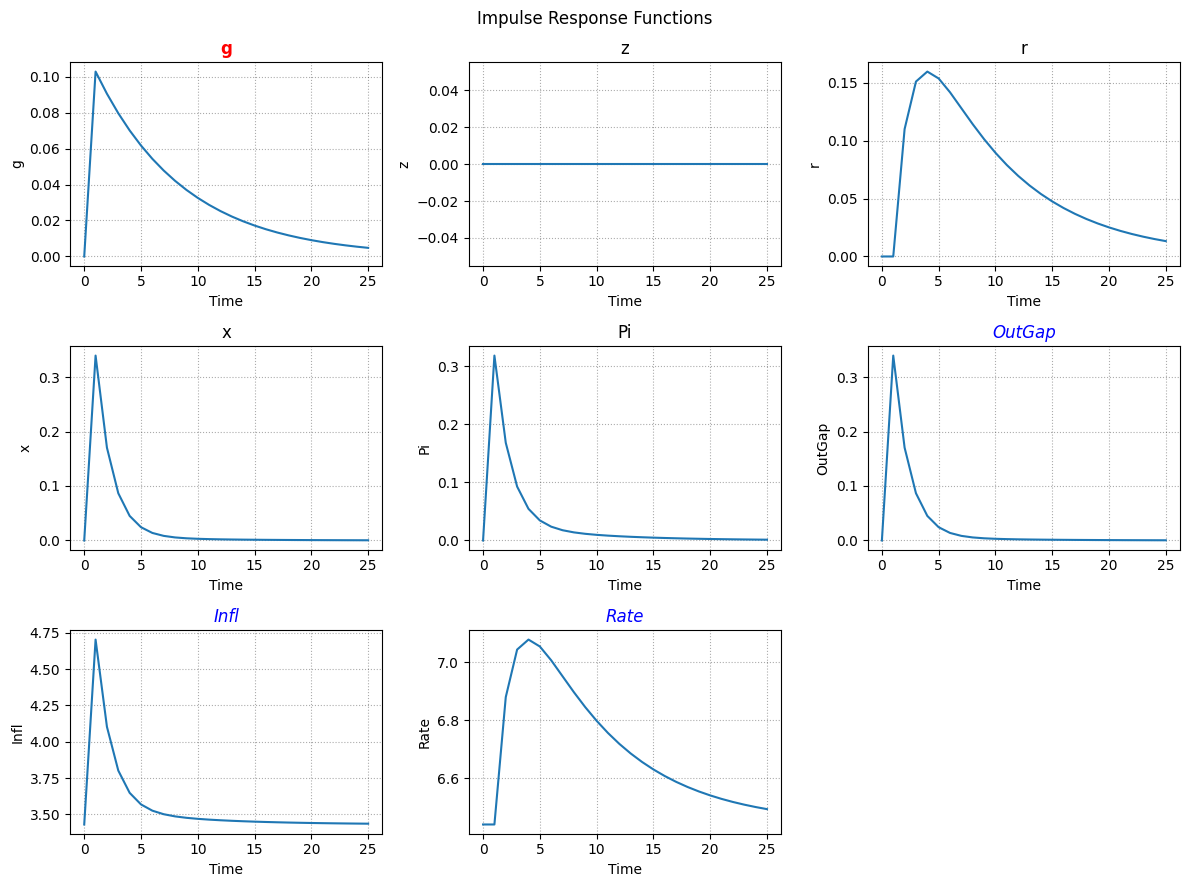

In [7]:
sol.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [8]:
res1, sol1 = estim(True)

MCMC sampling concluded in 27.51 seconds with 545.31 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


In [9]:
param_names1 = res1.param_names

post_mean1 = np.mean(res1.samples, axis=0)

loglik1 = np.mean(res1.logpost_trace)
accept_rate1 = res1.accept_rate
pd.Series(
    {
        **dict(zip(param_names1, post_mean1)),
        "loglik": loglik1,
        "accept_rate": accept_rate1,
        "n_draws": res1.n_draws,
        "burn_in": res1.burn_in,
        "thin": res1.thin,
    }
)

beta               0.999902
rho_r              0.769433
rho_g              0.878462
rho_z              0.852437
psi_pi             4.164204
psi_x              0.328895
kappa              0.312696
tau_inv            0.628903
rho_gz             0.252451
meas_rho_ir        0.189558
sig_r              0.027313
sig_g              0.139881
sig_z              0.445840
meas_infl          1.531622
meas_rate          0.063073
loglik          -385.444286
accept_rate        0.122800
n_draws        10000.000000
burn_in         5000.000000
thin               1.000000
dtype: float64

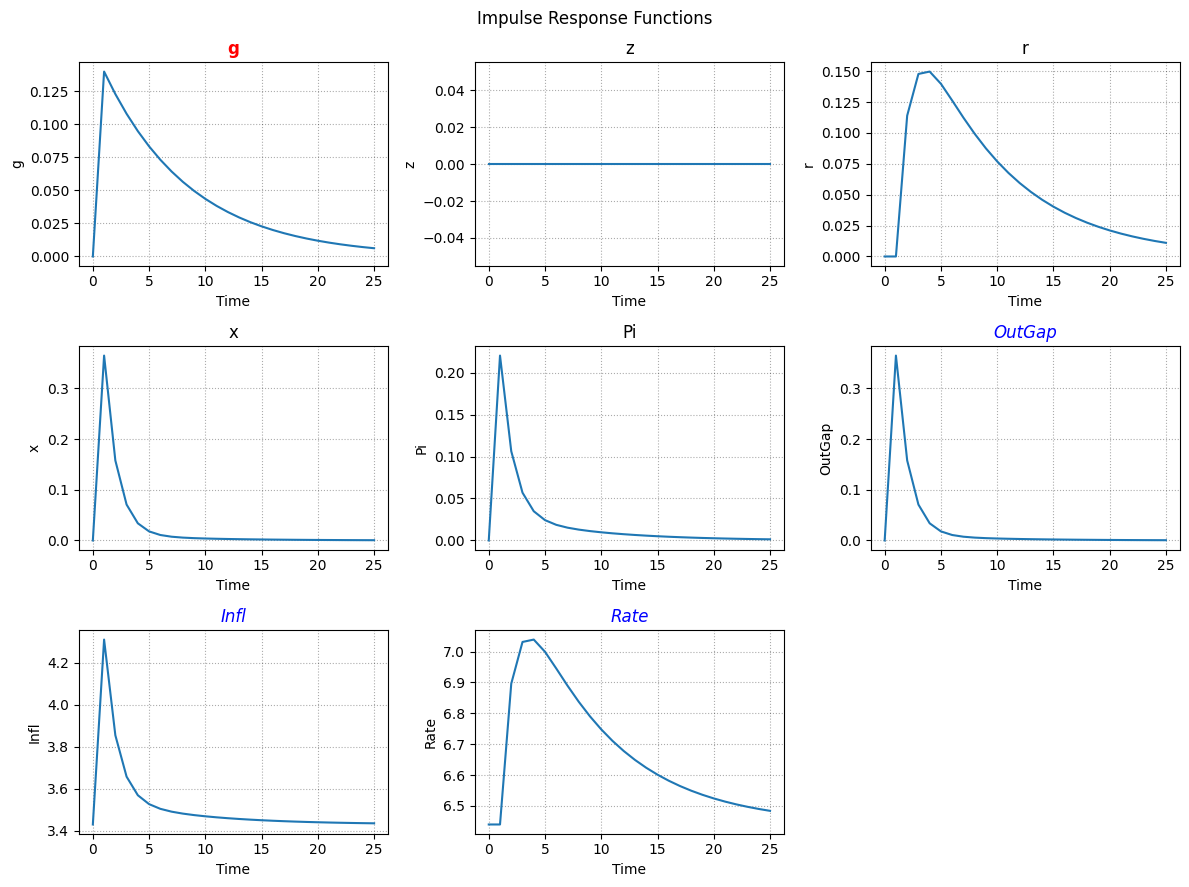

In [10]:
sol1.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [11]:
kf_0 = sol.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "linear",
    return_shocks=True,
)
kf_1 = sol1.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "linear",
    return_shocks=True,
)

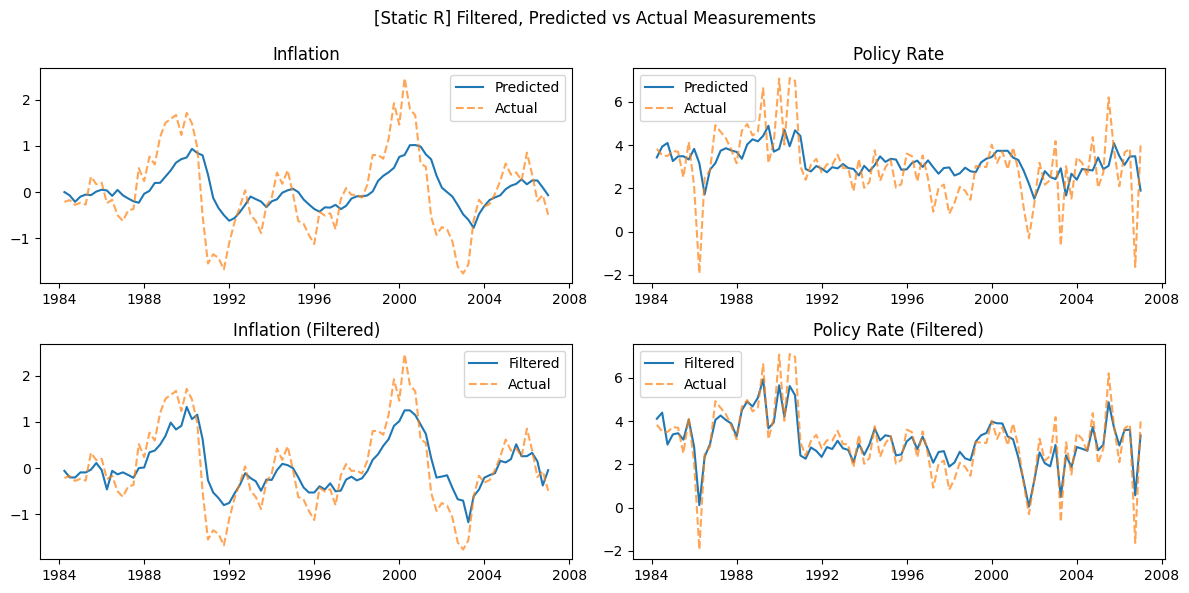

In [12]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(2, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle("[Static R] Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf_0.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Inflation")
ax[0].legend()

ax[1].plot(idx, kf_0.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Policy Rate")
ax[1].legend()

ax[2].plot(idx, kf_0.y_filt[:, 0], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Inflation (Filtered)")
ax[2].legend()

ax[3].plot(idx, kf_0.y_filt[:, 1], label="Filtered")
ax[3].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[3].set_title("Policy Rate (Filtered)")
ax[3].legend()

plt.tight_layout()

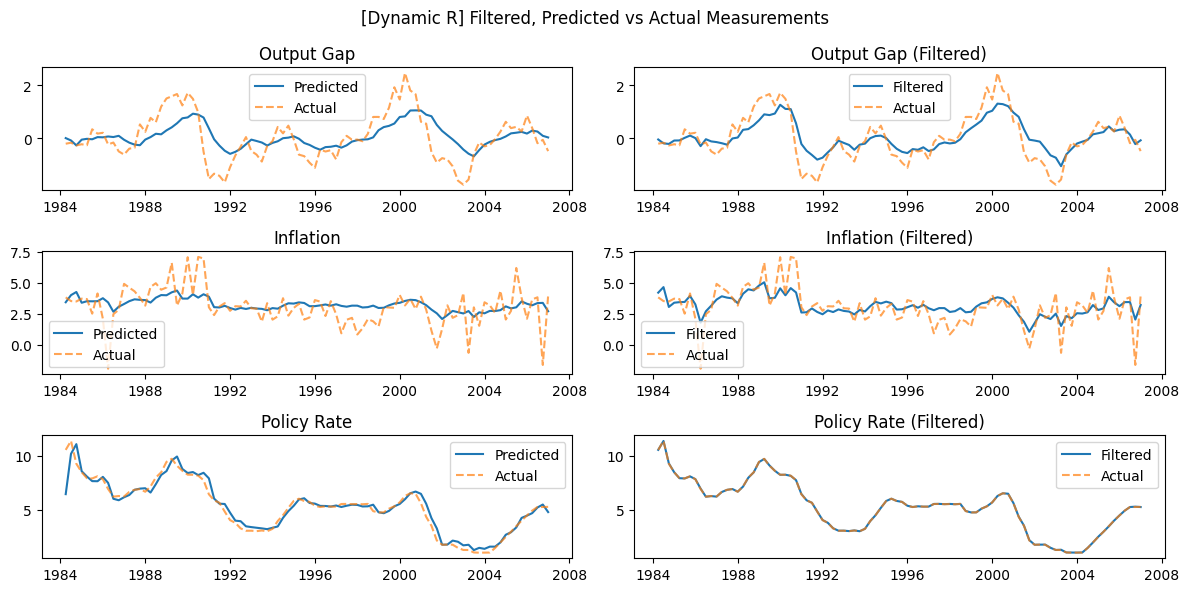

In [13]:
fig, ax = plt.subplots(3, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle("[Dynamic R] Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf_1.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf_1.y_filt[:, 0], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Output Gap (Filtered)")
ax[1].legend()

ax[2].plot(idx, kf_1.y_pred[:, 1], label="Predicted")
ax[2].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Inflation")
ax[2].legend()

ax[3].plot(idx, kf_1.y_filt[:, 1], label="Filtered")
ax[3].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[3].set_title("Inflation (Filtered)")
ax[3].legend()

ax[4].plot(idx, kf_1.y_pred[:, 2], label="Predicted")
ax[4].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[4].set_title("Policy Rate")
ax[4].legend()

ax[5].plot(idx, kf_1.y_filt[:, 2], label="Filtered")
ax[5].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[5].set_title("Policy Rate (Filtered)")
ax[5].legend()

plt.tight_layout()

In [14]:
gz = Shock(T=len(idx) - 1, dist="norm", multivar=True, seed=0).shock_generator()
r = Shock(T=len(idx) - 1, dist="norm", seed=1).shock_generator()
sim0 = sol.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)

sim1 = sol1.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)

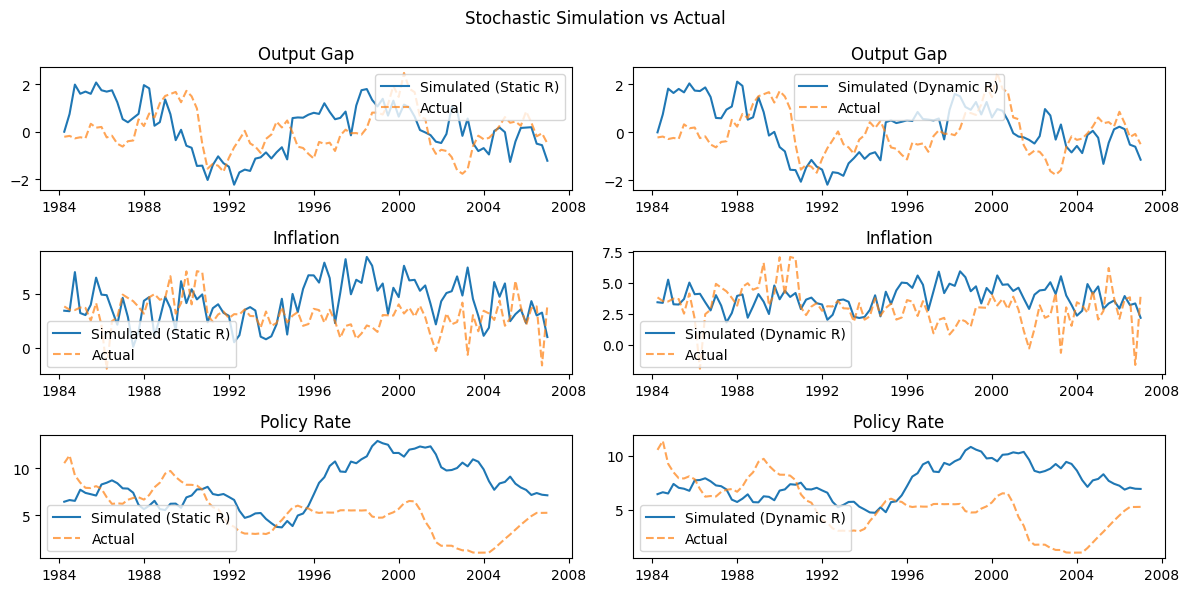

In [15]:
fig, ax = plt.subplots(3, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle("Stochastic Simulation vs Actual")

ax[0].plot(idx, sim0["OutGap"], label="Simulated (Static R)")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, sim1["OutGap"], label="Simulated (Dynamic R)")
ax[1].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Output Gap")
ax[1].legend()

ax[2].plot(idx, sim0["Infl"], label="Simulated (Static R)")
ax[2].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Inflation")
ax[2].legend()

ax[3].plot(idx, sim1["Infl"], label="Simulated (Dynamic R)")
ax[3].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[3].set_title("Inflation")
ax[3].legend()

ax[4].plot(idx, sim0["Rate"], label="Simulated (Static R)")
ax[4].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[4].set_title("Policy Rate")
ax[4].legend()

ax[5].plot(idx, sim1["Rate"], label="Simulated (Dynamic R)")
ax[5].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[5].set_title("Policy Rate")
ax[5].legend()

plt.tight_layout()

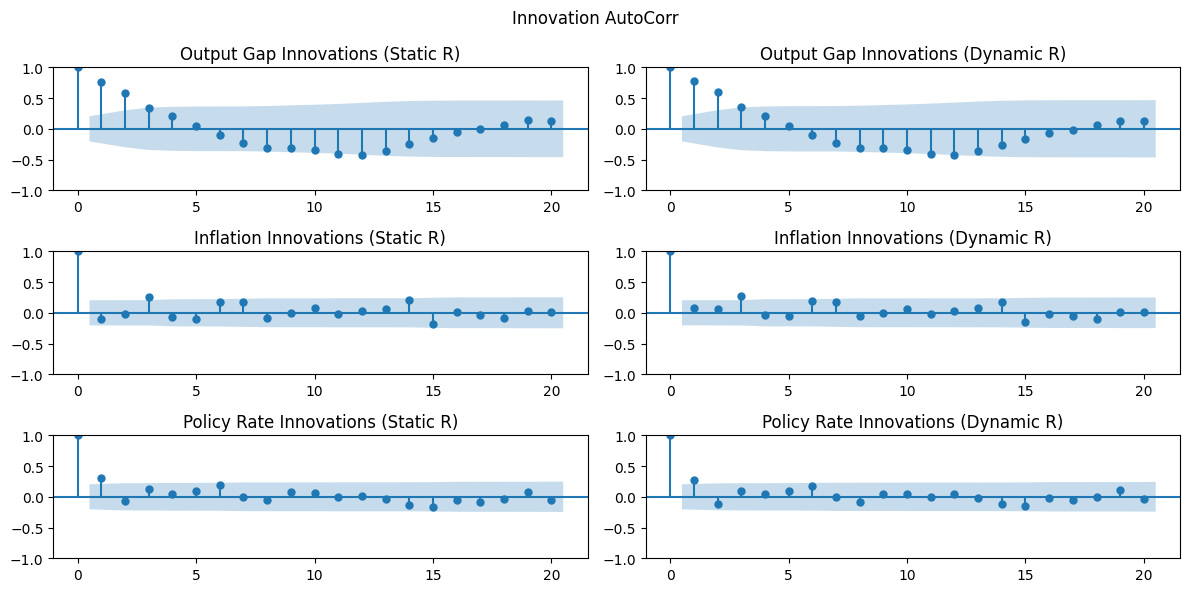

In [16]:
fig, ax = plt.subplots(3, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle("Innovation AutoCorr")

plot_acf(
    kf_0.innov[:, 0],
    ax=ax[0],
    lags=20,
    title="Output Gap Innovations (Static R)",
)
plot_acf(
    kf_1.innov[:, 0],
    ax=ax[1],
    lags=20,
    title="Output Gap Innovations (Dynamic R)",
)


plot_acf(
    kf_0.innov[:, 1],
    ax=ax[2],
    lags=20,
    title="Inflation Innovations (Static R)",
)
plot_acf(
    kf_1.innov[:, 1],
    ax=ax[3],
    lags=20,
    title="Inflation Innovations (Dynamic R)",
)

plot_acf(
    kf_0.innov[:, 2],
    ax=ax[4],
    lags=20,
    title="Policy Rate Innovations (Static R)",
)
plot_acf(
    kf_1.innov[:, 2],
    ax=ax[5],
    lags=20,
    title="Policy Rate Innovations (Dynamic R)",
)
plt.tight_layout()

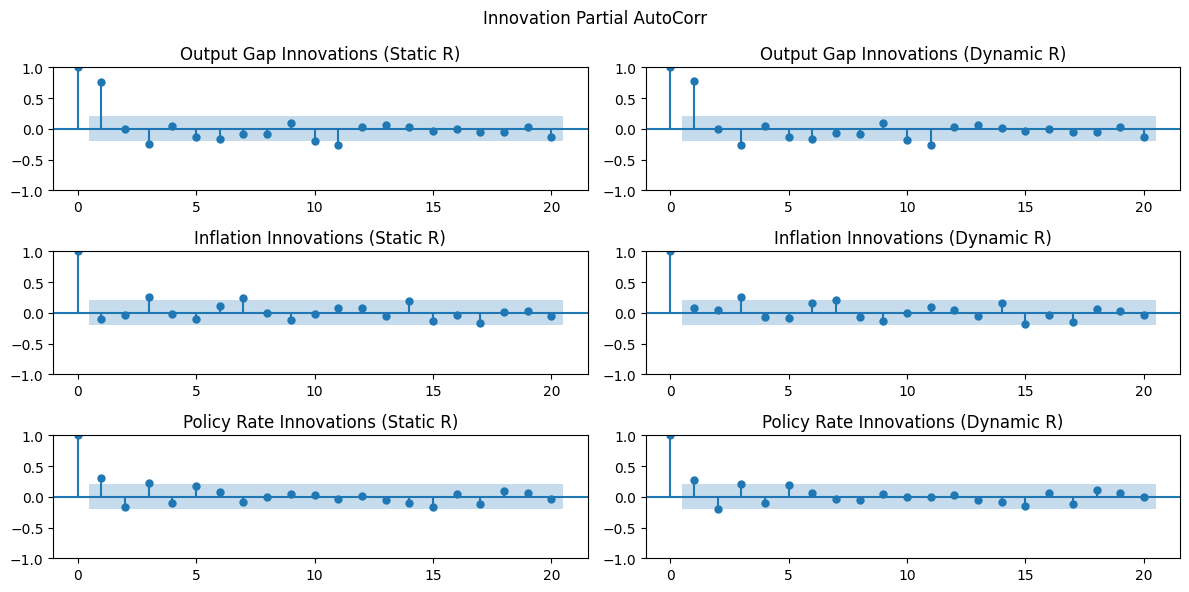

In [17]:
fig, ax = plt.subplots(3, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle("Innovation Partial AutoCorr")
plot_pacf(
    kf_0.innov[:, 0],
    ax=ax[0],
    lags=20,
    title="Output Gap Innovations (Static R)",
)
plot_pacf(
    kf_1.innov[:, 0],
    ax=ax[1],
    lags=20,
    title="Output Gap Innovations (Dynamic R)",
)

plot_pacf(
    kf_0.innov[:, 1],
    ax=ax[2],
    lags=20,
    title="Inflation Innovations (Static R)",
)
plot_pacf(
    kf_1.innov[:, 1],
    ax=ax[3],
    lags=20,
    title="Inflation Innovations (Dynamic R)",
)

plot_pacf(
    kf_0.innov[:, 2],
    ax=ax[4],
    lags=20,
    title="Policy Rate Innovations (Static R)",
)
plot_pacf(
    kf_1.innov[:, 2],
    ax=ax[5],
    lags=20,
    title="Policy Rate Innovations (Dynamic R)",
)
plt.tight_layout()

In [20]:
template = TemplateConfig(
    include_expression=False,
    interaction_form="func",
    hessian_restriction="free",
    power_law_lower_bound=2,
    power_law_upper_bound=2,
    powers_in_interactions=False,
    constant_filtering="parametrize_all",
)

params = PySRParams(
    niterations=200,
    maxsize=12,
    complexity_of_constants=1,
    complexity_of_variables=1,
    deterministic=True,
    random_state=0,
    parallelism="serial",
)

res = sol1.fit_kf(
    template_config=template,
    sr_params=params,
    y=observed.loc[observed.index >= "1984-01-01", :],
    variables=["r", "Pi", "x"],
    observable="OutGap",
).expressions

c:\Users\guney\Documents\GitHub\SymbolicDSGE\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 1.390e+05
Progress: 945 / 6200 total iterations (15.242%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.225e-01  0.000e+00  f_1 = #3
3           3.980e-01  2.986e-02  f_1 = #3 * 2.2621
5           3.939e-01  5.190e-03  f_1 = (#3 * 2.4948) - -0.070269
7           3.758e-01  2.348e-02  f_1 = (#1 * -0.61988) + (#3 * 5.1206)
9           3.746e-01  1.583e-03  f_1 = ((#1 * -0.61988) + (#3 * 5.1206)) + 0.036368
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.450e+05
Progress: 1952 / 6200 total iterations (31.484%

In [21]:
res

,complexity,loss,equation,score,julia_expression,lambda_format,sympy_format,initial_expr
0,1,0.422496,x,0.000000,f_1 = #3,<pysr.expression_specs.CallableJuliaExpression...,x,x
1,3,0.398006,_C_1*x,0.029857,f_1 = #3 * 2.2620614,<pysr.expression_specs.CallableJuliaExpression...,_C_1*x,2.2620614*x
2,5,0.384180,_C_1*r + _C_2*x,0.017677,f_1 = (#3 * 6.87283) - #1,<pysr.expression_specs.CallableJuliaExpression...,_C_1*r + _C_2*x,-r + 6.87283*x
3,7,0.375827,_C_1*x + _C_2*r,0.010991,f_1 = (#1 * -0.6197424) - (#3 * -5.119881),<pysr.expression_specs.CallableJuliaExpression...,_C_1*x + _C_2*r,-0.6197424*r + 5.119881*x
4,9,0.374351,_C_1 + _C_2*x + _C_3*r,0.001969,f_1 = ((#1 * -0.59130645) + (#3 * 5.1305194)) ...,<pysr.expression_specs.CallableJuliaExpression...,_C_1 + _C_2*x + _C_3*r,-0.59130645*r + 5.1305194*x + 0.042812645
5,11,0.350259,x*(_C_1 + _C_2*Pi/(_C_3 + r)),0.033260,f_1 = (2.3481963 - ((0.5201019 / (#1 + -0.3595...,<pysr.expression_specs.CallableJuliaExpression...,x*(_C_1 + _C_2*Pi/(_C_3 + r)),x*(-0.5201019*Pi/(r - 0.35951647) + 2.3481963)


In [ ]:
def sum_moments(series):
    out = pd.Series()

    out["mean"] = series.mean()
    out["var"] = series.var()
    out["Q1"] = series.quantile(0.25)
    out["Median"] = series.median()
    out["Q3"] = series.quantile(0.75)
    out["IQR"] = out["Q3"] - out["Q1"]
    return out.round(2)


sum_moments(pd.Series(kf_0.y_filt[:, 1]))

In [ ]:
print(res[["sympy_format", "loss", "complexity"]].to_latex())

In [ ]:
# Augmented Model
conf_aug, kalman_aug = ModelParser("./papers/progress/report1/Augmented.yaml").get_all()
solver_aug = DSGESolver(conf_aug, kalman_aug)
comp_aug = solver_aug.compile(n_exog=3, n_state=3)

aug = solver_aug.solve(compiled=comp_aug)  # Solve without re-estimation

In [ ]:
aug.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [ ]:
kf_aug = aug.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "extended",
    return_shocks=True,
)

In [ ]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(2, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle("Augmented Model: Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf_aug.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Inflation")
ax[0].legend()

ax[1].plot(idx, kf_aug.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Policy Rate")
ax[1].legend()

ax[2].plot(idx, kf_aug.y_filt[:, 0], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Inflation (Filtered)")
ax[2].legend()

ax[3].plot(idx, kf_aug.y_filt[:, 1], label="Filtered")
ax[3].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[3].set_title("Policy Rate (Filtered)")
ax[3].legend()

plt.tight_layout()

In [ ]:
sim_aug = aug.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)
fig, ax = plt.subplots(2, 1, figsize=(12, 6))

plt.suptitle("Augmented Model: Stochastic Simulation vs Actual")

ax[0].plot(idx, sim_aug["Infl"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Inflation")
ax[0].legend()

ax[1].plot(idx, sim_aug["Rate"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Policy Rate")
ax[1].legend()

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle("Augmented Model: Innovation AutoCorr")
plot_acf(kf_aug.innov[:, 0], ax=ax[0], lags=20, title="Inflation Innovations ACF")
plot_acf(kf_aug.innov[:, 1], ax=ax[1], lags=20, title="Policy Rate Innovationsc ACF")

plot_pacf(kf_aug.innov[:, 0], ax=ax[2], lags=20, title="Inflation Innovations PACF")
plot_pacf(kf_aug.innov[:, 1], ax=ax[3], lags=20, title="Policy Rate Innovations PACF")
plt.tight_layout()

In [ ]:
sum_moments(pd.Series(sim_aug["Infl"]))

In [ ]:
# Augmented + Re-estimated model

res_aug, sol_aug = solver_aug.estimate_and_solve(
    compiled=comp_aug,
    y=observed.loc[observed.index >= "1984-01-01", :],
    priors=prior_spec,
    method="mcmc",
    posterior_point="mean",
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    estimated_params=list(prior_spec.keys()),
    n_draws=1000,
    burn_in=500,
    thin=1,
)

In [ ]:
# Summarize results
param_names_aug = res_aug.param_names
post_mean_aug = np.mean(res_aug.samples, axis=0)
loglik_aug = np.mean(res_aug.logpost_trace)
accept_rate_aug = res_aug.accept_rate
pd.Series(
    {
        **dict(zip(param_names_aug, post_mean_aug)),
        "loglik": loglik_aug,
        "accept_rate": accept_rate_aug,
        "n_draws": res_aug.n_draws,
        "burn_in": res_aug.burn_in,
        "thin": res_aug.thin,
    }
)

In [ ]:
sol_aug.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [ ]:
kf_aug_reest = sol_aug.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "extended",
    return_shocks=True,
)

In [ ]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(2, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle(
    "Augmented + Re-estimated Model: Filtered, Predicted vs Actual Measurements"
)

ax[0].plot(idx, kf_aug_reest.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Inflation")
ax[0].legend()

ax[1].plot(idx, kf_aug_reest.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Policy Rate")
ax[1].legend()

ax[2].plot(idx, kf_aug_reest.y_filt[:, 0], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Inflation (Filtered)")
ax[2].legend()

ax[3].plot(idx, kf_aug_reest.y_filt[:, 1], label="Filtered")
ax[3].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[3].set_title("Policy Rate (Filtered)")
ax[3].legend()

plt.tight_layout()

In [ ]:
sim_aug_reest = sol_aug.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)
fig, ax = plt.subplots(2, 1, figsize=(12, 6))

plt.suptitle("Augmented + Re-estimated Model: Stochastic Simulation vs Actual")

ax[0].plot(idx, sim_aug_reest["Infl"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Inflation")
ax[0].legend()

ax[1].plot(idx, sim_aug_reest["Rate"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Policy Rate")
ax[1].legend()

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle("Augmented + Re-estimated Model: Innovation AutoCorr")
plot_acf(kf_aug_reest.innov[:, 0], ax=ax[0], lags=20, title="Inflation Innovations ACF")
plot_acf(
    kf_aug_reest.innov[:, 1], ax=ax[1], lags=20, title="Policy Rate Innovationsc ACF"
)
plot_pacf(
    kf_aug_reest.innov[:, 0], ax=ax[2], lags=20, title="Inflation Innovations PACF"
)
plot_pacf(
    kf_aug_reest.innov[:, 1], ax=ax[3], lags=20, title="Policy Rate Innovations PACF"
)
plt.tight_layout()

In [ ]:
res_aug.hpd_intervals()